<a href="https://colab.research.google.com/github/Mscient/30-Days-Of-Code/blob/master/IPL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


IPL 2023 Auction Analysis:

In [3]:
pool=pd.read_csv("/content/IPL_2023_Auction_Pool.csv")
sold=pd.read_csv("/content/IPL_2023_Auction_Sold.csv")

In [5]:
pool

,Set No.,2023 Set,First Name,Surname,Country,Association,DOB,Age,Specialism,Batting_Style,Bowling_Style,Test caps,ODI caps,T20 caps,IPL,Previous IPLTeam(s),2022 Team,2022 IPL,C/U/A,Reserve_Price
0,1,BA1,Mayank,Agarwal,India,KSCA,16/02/1991,32,BATSMAN,RHB,RIGHT ARM Off Spin,21,5,0,113,"RCB, DD, RPSG, PBKS",PBKS,13,Capped,100
1,1,BA1,Harry,Brook,England,F,22/02/1999,24,BATSMAN,RHB,RIGHT ARM Medium,1,0,20,0,Do No Play,Do No Play,0,Capped,150
2,1,BA1,Ajinkya,Rahane,India,MCA,06/06/1988,34,BATSMAN,RHB,-,82,90,20,158,"MI, RPSG, RR, DC, KKR",KKR,7,Capped,50
3,1,BA1,Joe,Root,England,F,30/12/1990,32,BATSMAN,RHB,RIGHT ARM Off Spin,124,158,32,0,Do No Play,Do No Play,0,Capped,100
4,1,BA1,Rilee,Rossouw,South Africa,F,09/10/1989,33,BATSMAN,LHB,-,0,36,26,5,RCB,Do No Play,0,Capped,200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400,43,UAL10,Jack,Prestwidge,Australia,F,28/02/1996,27,ALL-ROUNDER,RHB,RIGHT ARM Fast,0,0,0,0,Do No Play,Do No Play,0,Uncapped,20
401,43,UAL10,Aditya,Sarvate,India,VCA,10/12/1989,33,ALL-ROUNDER,RHB,LEFT ARM Slow Orthodox,0,0,0,0,Do No Play,Do No Play,0,Uncapped,20
402,43,UAL10,Sagar,Solanki,India,MPCA,01/01/2000,23,ALL-ROUNDER,LHB,LEFT ARM Slow Unorthodox,0,0,0,0,Do No Play,Do No Play,0,Uncapped,20
403,43,UAL10,Prenelan,Subrayen,South Africa,F,23/09/1993,29,ALL-ROUNDER,RHB,RIGHT ARM Off Spin,0,0,0,0,Do No Play,Do No Play,0,Uncapped,20


EDA


In [7]:
pool.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405 entries, 0 to 404
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Set No.              405 non-null    int64 
 1   2023 Set             405 non-null    object
 2   First Name           405 non-null    object
 3   Surname              405 non-null    object
 4   Country              405 non-null    object
 5   Association          405 non-null    object
 6   DOB                  405 non-null    object
 7   Age                  405 non-null    int64 
 8   Specialism           405 non-null    object
 9   Batting_Style        405 non-null    object
 10  Bowling_Style        405 non-null    object
 11  Test caps            405 non-null    int64 
 12  ODI caps             405 non-null    int64 
 13  T20 caps             405 non-null    int64 
 14  IPL                  405 non-null    int64 
 15  Previous IPLTeam(s)  405 non-null    object
 16  2022 Tea

In [8]:
list(pool.columns)

['Set No.',
 '2023 Set',
 'First Name',
 'Surname',
 'Country',
 'Association',
 'DOB',
 'Age',
 'Specialism',
 'Batting_Style',
 'Bowling_Style',
 'Test caps',
 'ODI caps',
 'T20 caps',
 'IPL',
 'Previous IPLTeam(s)',
 '2022 Team',
 '2022 IPL',
 'C/U/A',
 'Reserve_Price']

In [11]:
pool.shape
pool[['First Name','Surname']][0:9]

,First Name,Surname
0,Mayank,Agarwal
1,Harry,Brook
2,Ajinkya,Rahane
3,Joe,Root
4,Rilee,Rossouw
5,Kane,Williamson
6,Sam,Curran
7,Cameron,Green
8,Shakib Al,Hasan


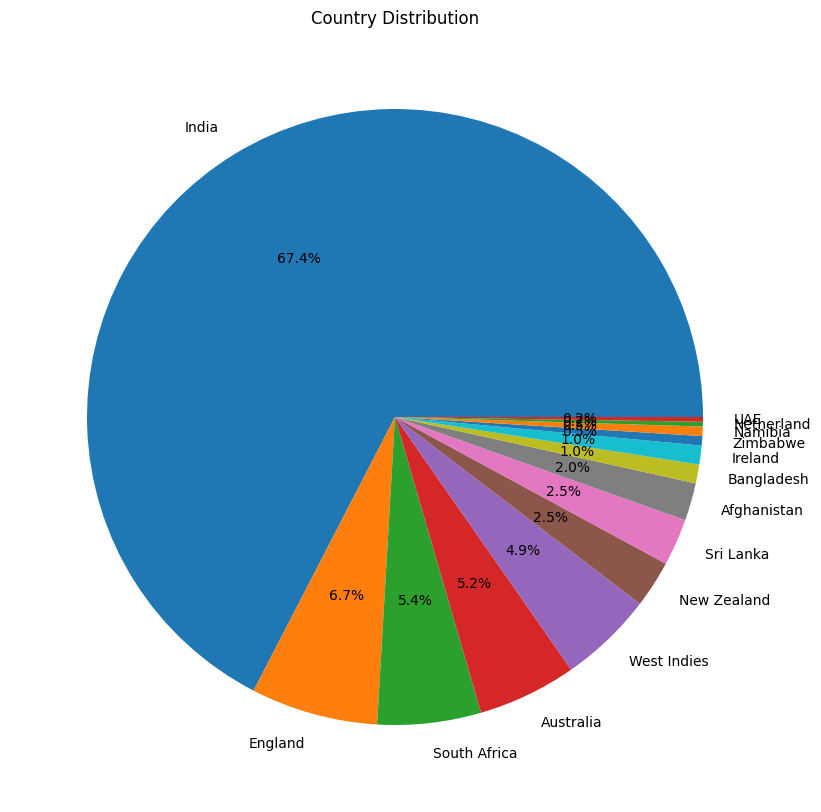

In [14]:
country_count=pool['Country'].value_counts()
plt.figure(figsize=(12,10))
plt.pie(country_count,labels=country_count.index,autopct='%1.1f%%')
plt.title('Country Distribution')
plt.show()


In [22]:
sold.assign(Actual_Price=sold['Reserve_Price']*100000)[['First Name','Surname','Actual_Price']].sort_values('Actual_Price')

,First Name,Surname,Actual_Price
402,Sagar,Solanki,2000000
401,Aditya,Sarvate,2000000
384,Shamshuzama,Kazi,2000000
385,Ayaz,Khan,2000000
386,Amit,Pachhara,2000000
...,...,...,...
12,Ben,Stokes,20000000
247,Tymal,Mills,20000000
7,Cameron,Green,20000000
6,Sam,Curran,20000000


AGE VS SPECAILISM CROSSTAB...

In [24]:
pd.crosstab(pool['Age'],pool['Specialism'])

Specialism,ALL-ROUNDER,BATSMAN,BOWLER,WICKETKEEPER
Age,,,,
15,0,0,1,0
18,2,1,1,2
19,3,3,5,1
20,9,1,7,5
21,4,4,5,4
22,12,2,9,0
23,10,1,8,4
24,14,10,11,3
25,17,5,7,4


In [37]:
df=pool.groupby('Age')['Reserve_Price'].mean().reset_index()



In [54]:
combined=pool.merge(sold,on='First Name',how='outer').reset_index()
combined=combined[combined['TEAM'] !='UnSold']
combined['more_than']=combined['Auction_Price']-combined['Reserve_Price_x']
combined

,index,Set No._x,2023 Set_x,First Name,Surname_x,Country_x,Association_x,DOB_x,Age_x,Specialism_x,...,T20 caps_y,IPL_y,Previous IPLTeam(s)_y,2022 Team_y,2022 IPL_y,C/U/A_y,Reserve_Price_y,TEAM,Auction_Price,more_than
7,7,4,FA1,Adam,Milne,New Zealand,F,13/04/1992,30,BOWLER,...,72,14,"RPSG, RCB",Do No Play,0,Capped,150,RR,150.0,-50.0
9,9,5,SP1,Adam,Zampa,Australia,F,31/12/1992,30,BOWLER,...,72,14,"RPSG, RCB",Do No Play,0,Capped,150,RR,150.0,0.0
10,10,5,SP1,Adil,Rashid,England,F,17/02/1988,35,BOWLER,...,92,1,PBKS,Do No Play,0,Capped,200,SRH,200.0,0.0
15,15,34,UFA4,Ajay,Sarkar,India,TCA,10/03/1997,26,BOWLER,...,0,0,Do No Play,Do No Play,0,Uncapped,20,CSK,20.0,0.0
17,17,38,UAL6,Ajay,Mandal,India,CSCSCA,25/02/1996,27,ALL-ROUNDER,...,0,0,Do No Play,Do No Play,0,Uncapped,20,CSK,20.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545,545,11,BA2,Will,Jacks,England,F,21/11/1998,24,BATSMAN,...,2,0,Do No Play,Do No Play,0,Capped,150,RCB,320.0,170.0
547,547,16,UBA2,Will,Smeed,England,F,26/10/2001,21,BATSMAN,...,2,0,Do No Play,Do No Play,0,Capped,150,RCB,320.0,280.0
550,550,9,UFA1,Yash,Thakur,India,VCA,28/12/1998,24,BOWLER,...,0,0,Do No Play,Do No Play,0,Uncapped,20,LSG,45.0,25.0
552,552,26,UWK3,Yash,Kothari,India,RCA,06/10/1995,27,WICKETKEEPER,...,0,0,Do No Play,Do No Play,0,Uncapped,20,LSG,45.0,25.0


In [57]:
combined.rename(columns={'more_than':'profit'},inplace=True)
combined

,index,Set No._x,2023 Set_x,First Name,Surname_x,Country_x,Association_x,DOB_x,Age_x,Specialism_x,...,T20 caps_y,IPL_y,Previous IPLTeam(s)_y,2022 Team_y,2022 IPL_y,C/U/A_y,Reserve_Price_y,TEAM,Auction_Price,profit
7,7,4,FA1,Adam,Milne,New Zealand,F,13/04/1992,30,BOWLER,...,72,14,"RPSG, RCB",Do No Play,0,Capped,150,RR,150.0,-50.0
9,9,5,SP1,Adam,Zampa,Australia,F,31/12/1992,30,BOWLER,...,72,14,"RPSG, RCB",Do No Play,0,Capped,150,RR,150.0,0.0
10,10,5,SP1,Adil,Rashid,England,F,17/02/1988,35,BOWLER,...,92,1,PBKS,Do No Play,0,Capped,200,SRH,200.0,0.0
15,15,34,UFA4,Ajay,Sarkar,India,TCA,10/03/1997,26,BOWLER,...,0,0,Do No Play,Do No Play,0,Uncapped,20,CSK,20.0,0.0
17,17,38,UAL6,Ajay,Mandal,India,CSCSCA,25/02/1996,27,ALL-ROUNDER,...,0,0,Do No Play,Do No Play,0,Uncapped,20,CSK,20.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545,545,11,BA2,Will,Jacks,England,F,21/11/1998,24,BATSMAN,...,2,0,Do No Play,Do No Play,0,Capped,150,RCB,320.0,170.0
547,547,16,UBA2,Will,Smeed,England,F,26/10/2001,21,BATSMAN,...,2,0,Do No Play,Do No Play,0,Capped,150,RCB,320.0,280.0
550,550,9,UFA1,Yash,Thakur,India,VCA,28/12/1998,24,BOWLER,...,0,0,Do No Play,Do No Play,0,Uncapped,20,LSG,45.0,25.0
552,552,26,UWK3,Yash,Kothari,India,RCA,06/10/1995,27,WICKETKEEPER,...,0,0,Do No Play,Do No Play,0,Uncapped,20,LSG,45.0,25.0


Data Visualisation


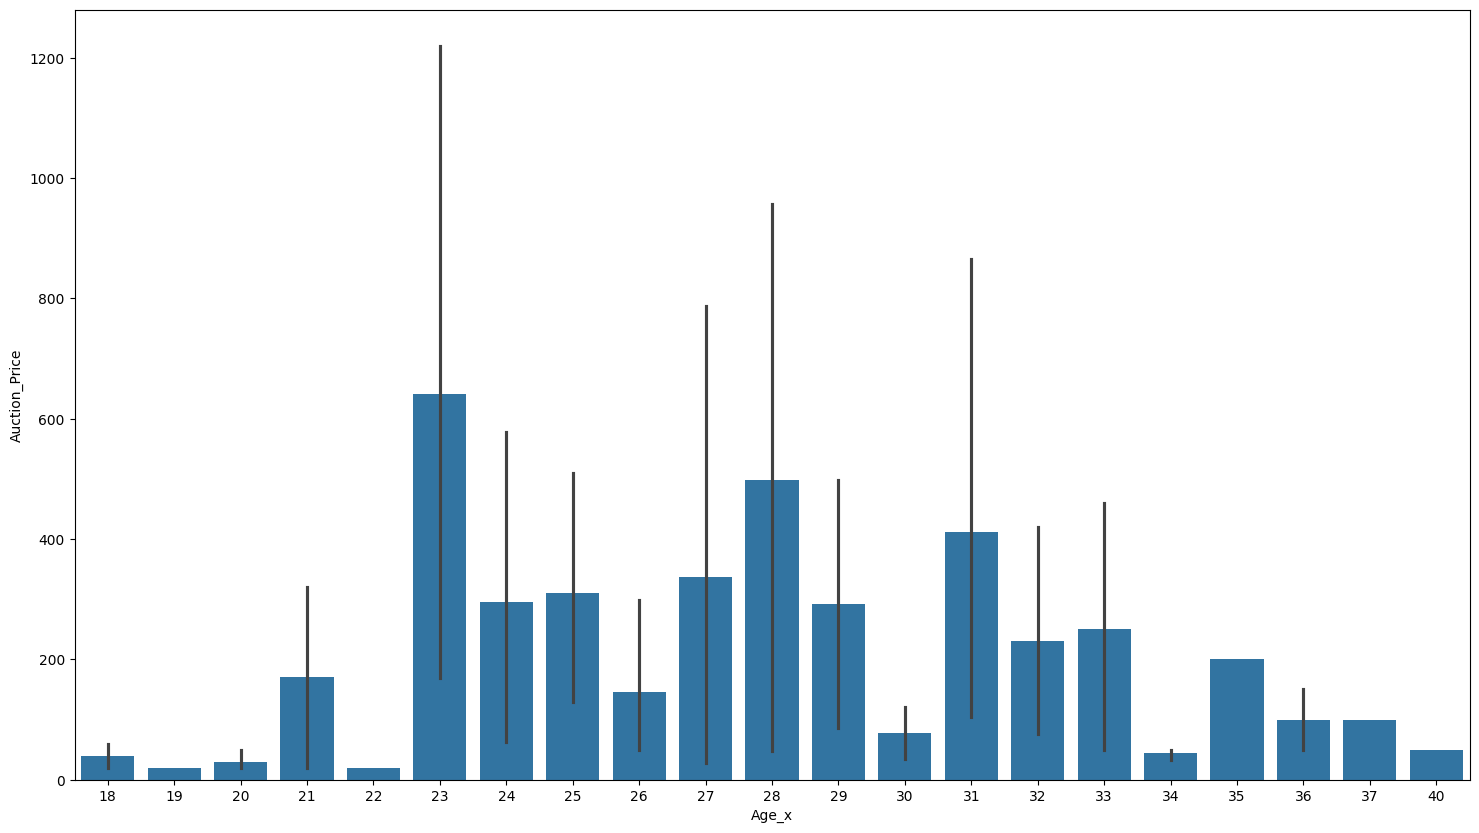

In [64]:
plt.figure(figsize=(18,10))
sns.barplot(y='Auction_Price',x='Age_x',data=combined);

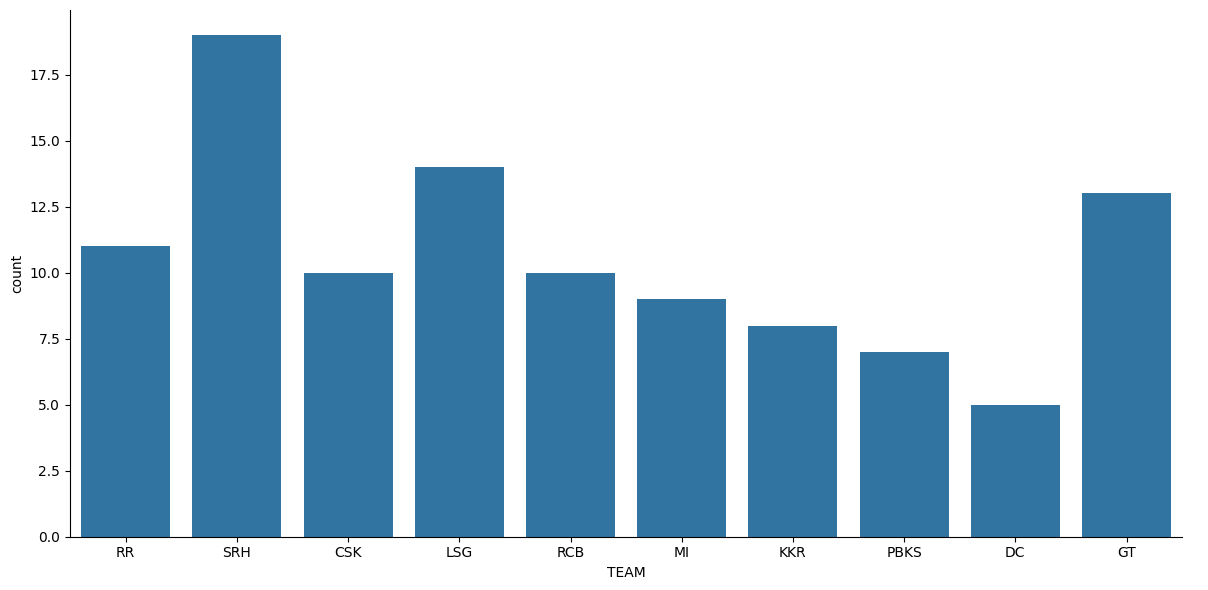

In [65]:
sns.catplot(data=sold_only, x='TEAM', kind='count', height=6, aspect=2)
# height = vertical size
# aspect = how much wider it is than the height (2 means twice as wide)

<Axes: xlabel='Specialism_x', ylabel='Auction_Price'>

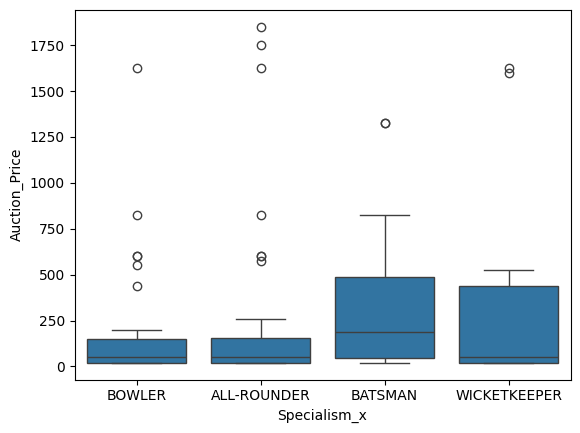

In [107]:
sns.boxplot(x='Specialism_x',y='Auction_Price',data=combined)

(array([ 3.,  7., 11., 69.,  5.,  1.,  4.,  2.,  2.,  2.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 <BarContainer object of 10 artists>)

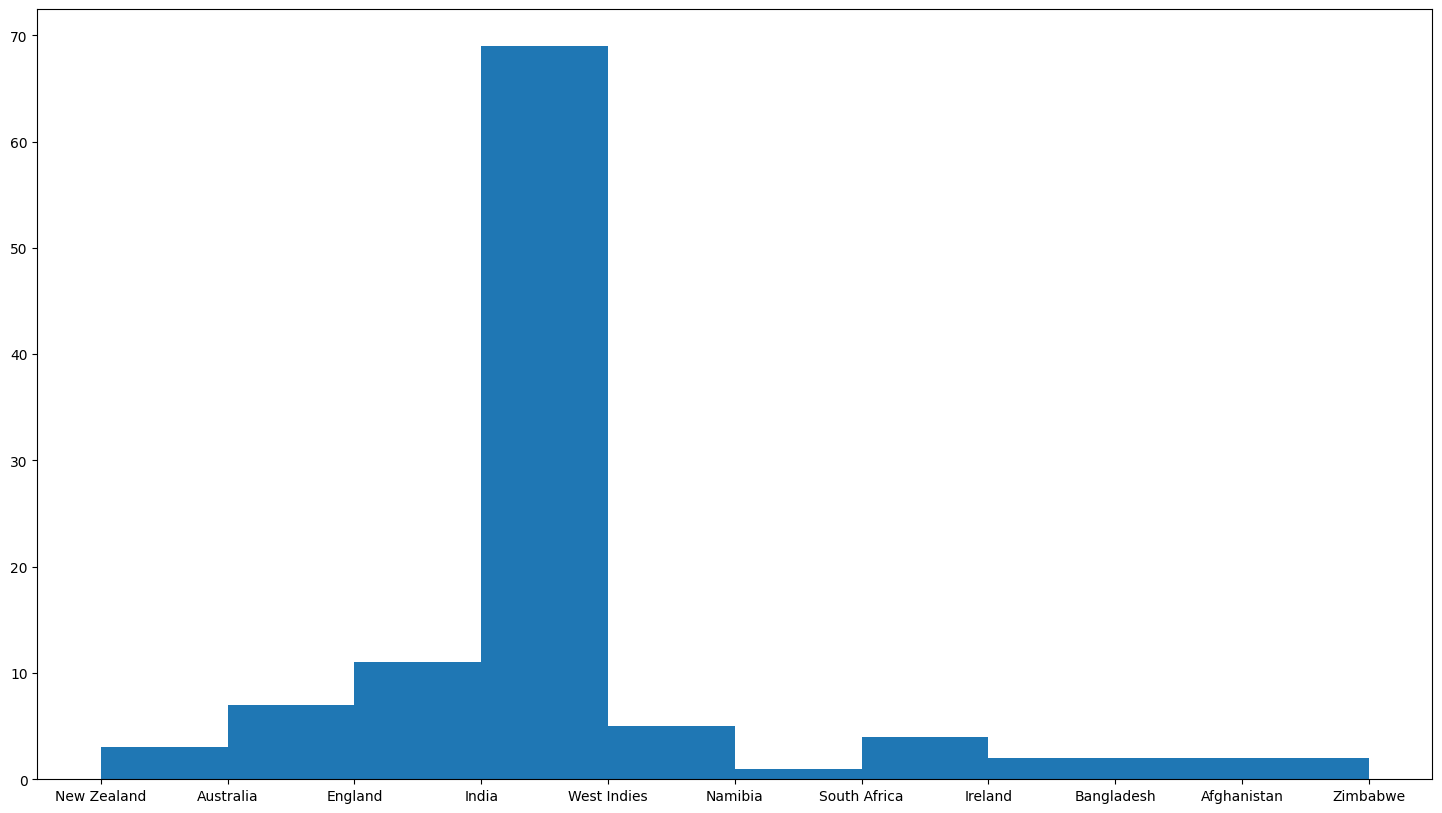

In [80]:
plt.figure(figsize=(18,10))
plt.hist(combined['Country_x'])

(array([68., 11.,  2.,  2.,  3.,  2.,  7.,  0.,  3.,  0.,  0.,  0.,  0.,
         0.,  2.,  0.,  0.,  4.,  1.,  1.]),
 array([  20. ,  111.5,  203. ,  294.5,  386. ,  477.5,  569. ,  660.5,
         752. ,  843.5,  935. , 1026.5, 1118. , 1209.5, 1301. , 1392.5,
        1484. , 1575.5, 1667. , 1758.5, 1850. ]),
 <BarContainer object of 20 artists>)

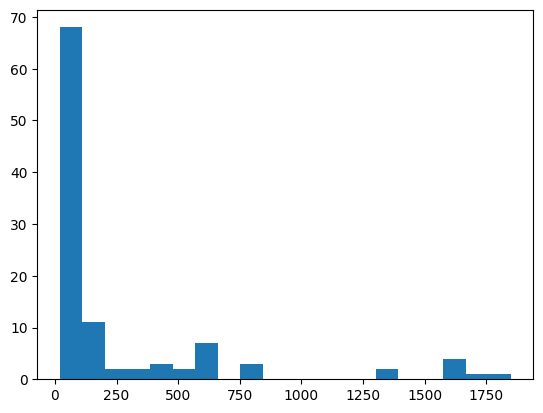

In [87]:
combined=combined[combined['Auction_Price']>0]
plt.hist(combined['Auction_Price'],bins=20)

/tmp/ipykernel_1472/3915197848.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(combined['Auction_Price'])


<Axes: xlabel='Auction_Price', ylabel='Density'>

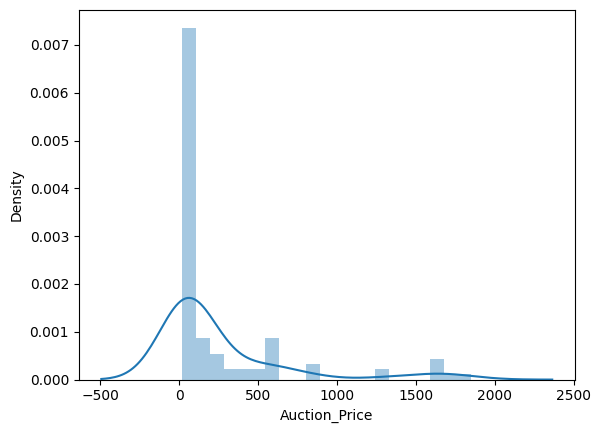

In [88]:
sns.distplot(combined['Auction_Price'])


<Axes: ylabel='Auction_Price'>

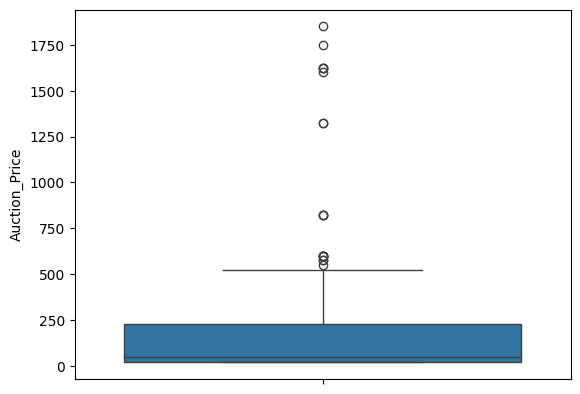

In [89]:
sns.boxplot(combined['Auction_Price'])

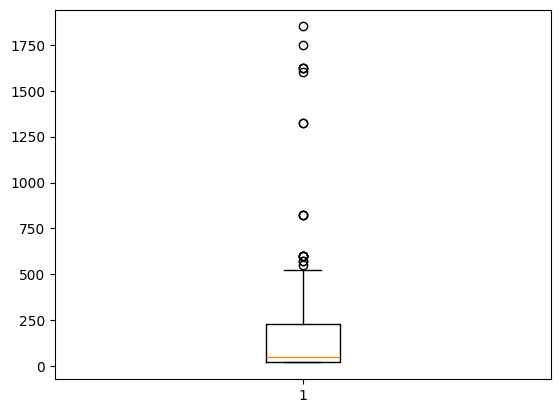

In [93]:
box=plt.boxplot(combined['Auction_Price'])

In [96]:
[item.get_ydata() [0] for item in box['T20caps_y']]

KeyError: 'T20caps_y'

In [102]:
from matplotlib.cbook import boxplot_stats

# This gives you a dictionary of all the statistics directly
stats = boxplot_stats(combined['Auction_Price'])[0]

print(f"Minimum (Cap): {stats['whislo']}")
print(f"Maximum (Cap): {stats['whishi']}")
print(f"Median: {stats['med']}")

Minimum (Cap): 20.0
Maximum (Cap): 525.0
Median: 50.0


In [98]:
stats

{'mean': np.float64(259.62264150943395),
 'iqr': np.float64(210.0),
 'cilo': np.float64(17.976705118081),
 'cihi': np.float64(82.023294881919),
 'whishi': np.float64(525.0),
 'whislo': np.float64(20.0),
 'fliers': array([1625., 1625., 1625., 1750., 1325., 1325.,  575.,  575.,  825.,
         825.,  825.,  550., 1600., 1850.,  600.,  600.,  600.,  600.,
         600.]),
 'q1': np.float64(20.0),
 'med': np.float64(50.0),
 'q3': np.float64(230.0)}

In [103]:
combined

,index,Set No._x,2023 Set_x,First Name,Surname_x,Country_x,Association_x,DOB_x,Age_x,Specialism_x,...,T20 caps_y,IPL_y,Previous IPLTeam(s)_y,2022 Team_y,2022 IPL_y,C/U/A_y,Reserve_Price_y,TEAM,Auction_Price,profit
7,7,4,FA1,Adam,Milne,New Zealand,F,13/04/1992,30,BOWLER,...,72,14,"RPSG, RCB",Do No Play,0,Capped,150,RR,150.0,-50.0
9,9,5,SP1,Adam,Zampa,Australia,F,31/12/1992,30,BOWLER,...,72,14,"RPSG, RCB",Do No Play,0,Capped,150,RR,150.0,0.0
10,10,5,SP1,Adil,Rashid,England,F,17/02/1988,35,BOWLER,...,92,1,PBKS,Do No Play,0,Capped,200,SRH,200.0,0.0
15,15,34,UFA4,Ajay,Sarkar,India,TCA,10/03/1997,26,BOWLER,...,0,0,Do No Play,Do No Play,0,Uncapped,20,CSK,20.0,0.0
17,17,38,UAL6,Ajay,Mandal,India,CSCSCA,25/02/1996,27,ALL-ROUNDER,...,0,0,Do No Play,Do No Play,0,Uncapped,20,CSK,20.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545,545,11,BA2,Will,Jacks,England,F,21/11/1998,24,BATSMAN,...,2,0,Do No Play,Do No Play,0,Capped,150,RCB,320.0,170.0
547,547,16,UBA2,Will,Smeed,England,F,26/10/2001,21,BATSMAN,...,2,0,Do No Play,Do No Play,0,Capped,150,RCB,320.0,280.0
550,550,9,UFA1,Yash,Thakur,India,VCA,28/12/1998,24,BOWLER,...,0,0,Do No Play,Do No Play,0,Uncapped,20,LSG,45.0,25.0
552,552,26,UWK3,Yash,Kothari,India,RCA,06/10/1995,27,WICKETKEEPER,...,0,0,Do No Play,Do No Play,0,Uncapped,20,LSG,45.0,25.0


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


<Figure size 1800x1000 with 0 Axes>

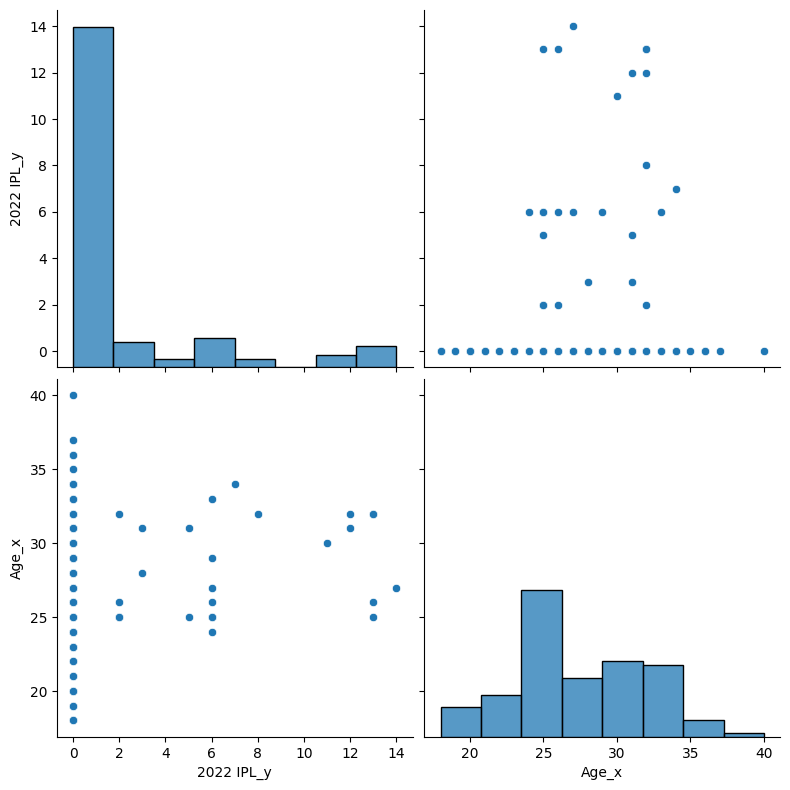

In [113]:
plt.figure(figsize=(18,10))
influential_factors=['2023 Set_x','Specialism_x','2022 IPL_y','Age_x']
sns.pairplot(combined[influential_factors],size=4)